In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats

font_file_candidates = [
    '/System/Library/Fonts/AppleSDGothicNeo.ttc',
    '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
]
selected_font_file = next((font for font in font_file_candidates if os.path.exists(font)), None)
font_name = None
if selected_font_file is not None:
    try:
        fm.fontManager.addfont(selected_font_file)
    except Exception:
        pass
    font_name = fm.FontProperties(fname=selected_font_file).get_name()
    print(f'사용 폰트 파일: {selected_font_file}')
    print(f'적용 폰트 이름: {font_name}')
else:
    print('사용 가능한 한글 폰트 파일을 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.')

# seaborn보다 먼저 matplotlib 기본 폰트를 고정합니다.
if font_name is not None:
    mpl.rcParams.update({
        'font.family': font_name,
        'font.sans-serif': [font_name],
        'axes.unicode_minus': False,
        'svg.fonttype': 'none'
    })

sns.set_theme(
    style='whitegrid',
    rc={
        'font.family': font_name if font_name is not None else 'sans-serif',
        'font.sans-serif': [font_name] if font_name is not None else ['DejaVu Sans'],
        'axes.unicode_minus': False
    }
)

if font_name is not None:
    plt.rcParams['font.family'] = font_name
    plt.rcParams['font.sans-serif'] = [font_name]
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print('현재 matplotlib font.family:', mpl.rcParams['font.family'])
print('현재 matplotlib font.sans-serif:', mpl.rcParams['font.sans-serif'])


사용 폰트 파일: /System/Library/Fonts/AppleSDGothicNeo.ttc
적용 폰트 이름: Apple SD Gothic Neo
현재 matplotlib font.family: ['Apple SD Gothic Neo']
현재 matplotlib font.sans-serif: ['Apple SD Gothic Neo']


In [2]:
df= pd.read_csv(r'/Users/gggyyu/Desktop/(아이엠뱅크) 2025 교육용 데이터/(아이엠뱅크) 2025 교육용 데이터.csv', encoding='cp949')
df_b = pd.read_csv(r"/Users/gggyyu/im_bank/project_1/iM뱅크_금리현황_2022-2024.csv")

In [3]:
count_mapping = {
    "0건": 0,
    "1건": 1,
    "2건": 2,
    "2건초과 5건이하": 3.5,
    "5건초과 10건이하": 7.5,
    "10건초과 20건이하": 15,
    "20건초과 30건이하": 25,
    "30건초과 40건이하": 35,
    "40건초과 50건이하": 45,
    "50건 초과": 55,
}

channel_count_cols = [
    "인터넷뱅킹거래건수",
    "스마트뱅킹거래건수",
    "폰뱅킹거래건수",
    "자동이체거래건수",
    "창구거래건수",
    "ATM거래건수",
    "외환_수출실적거래건수",
    "외환_수입실적거래건수",
]

for col in channel_count_cols:
    if col in df.columns:
        df[col] = df[col].map(count_mapping)

account_mapping = {
    "0개": 0,
    "1개": 1,
    "2개": 2,
    "2개초과 5개이하": 4,
    "5개초과 10개이하": 8,
    "10개초과 20개이하": 15.5,
    "20개초과 30개이하": 25.5,
    "30개초과 40개이하": 35.5,
    "40개초과 50개이하": 45.5,
    "50개 초과": 55,
}

account_count_cols = [
    "요구불예금좌수",
    "거치식예금좌수",
    "적립식예금좌수",
    "수익증권좌수",
    "신탁좌수",
    "퇴직연금좌수",
    "여신_운전자금대출좌수",
    "여신_시설자금대출좌수",
    "신용카드개수",
]

for col in account_count_cols:
    if col in df.columns:
        df[col] = df[col].map(account_mapping)

In [4]:
# 1. 자산성 지표 (Asset)
# 근거: 법인의 현금 동원력과 재무 안정성을 나타냄. 
# 단순히 합치지 않고 '요구불(유동성)'과 '장기저축성'을 묶어 법인의 자금 성격을 파악.
deposit_bal_cols = ["요구불예금잔액", "거치식예금잔액", "적립식예금잔액"]  
product_bal_cols = ["수익증권잔액", "신탁잔액", "퇴직연금잔액"]  
deposit_cnt_cols = ["요구불예금좌수", "거치식예금좌수", "적립식예금좌수"]  
product_cnt_cols = ["수익증권좌수", "신탁좌수", "퇴직연금좌수"]  
flow_cols = ["요구불입금금액", "요구불출금금액"]

# 2. 여신(대출) 지표 (Debt)
# 근거: 운전자금(운영비)과 시설자금(투자)을 구분. 
# 시설자금 비중이 높으면 공장이나 설비를 가진 '제조/생산형 법인'일 확률이 매우 높음.
loan_bal_cols = ["여신_운전자금대출잔액", "여신_시설자금대출잔액"]  
loan_cnt_cols = ["여신_운전자금대출좌수", "여신_시설자금대출좌수"]
 
# 3. 영업 거래 지표 (Transaction)
# 근거: 창구 거래가 많으면 '전통적/오프라인', 스마트뱅킹이 많으면 '젊은/온라인' 기업.
# 자동이체와 카드 사용액은 기업의 활동성을 대변함.

rjfo_total = ['인터넷뱅킹거래금액', '폰뱅킹거래금액' , '스마트뱅킹거래금액', '창구거래금액', 'ATM거래금액']
rjfo_digital = ['인터넷뱅킹거래금액', '폰뱅킹거래금액' , '스마트뱅킹거래금액']
rjfo_offline = ['창구거래금액', 'ATM거래금액']

rjfo_card_total = ['신용카드사용금액', '체크카드사용금액']

channel_cnt_cols = [  
   "창구거래건수",  
   "인터넷뱅킹거래건수",  
   "스마트뱅킹거래건수",  
   "폰뱅킹거래건수",  
   "ATM거래건수",  
]

# 4. 대외 무역 지표 (Global)
# 근거: 수출입 실적은 공단 지역(달성군, 북구 등) 보간의 결정적 근거.
dhlghks = ['외환_수출실적금액', '외환_수입실적금액']



In [5]:
# 피처 생성
df['총예금잔액'] = df[deposit_bal_cols].sum(axis=1)
df['자산관리잔액'] = df[product_bal_cols].sum(axis=1)
df['총대출잔액'] = df[loan_bal_cols].sum(axis=1)
df['총예금좌수'] = df[deposit_cnt_cols].sum(axis=1)
df['총대출좌수'] = df[loan_cnt_cols].sum(axis=1)
df['자산관리좌수']= df[product_cnt_cols].sum(axis=1)
df['총요구불입출금'] = df[flow_cols].sum(axis=1)

df['전체거래액'] = df[rjfo_total].sum(axis=1)
df['총디지털거래액'] = df[rjfo_digital].sum(axis=1)
df['총오프라인거래액'] = df[rjfo_offline].sum(axis=1)
df['총카드소비'] = df[rjfo_card_total].sum(axis=1)

df['총외환실적'] = df[dhlghks].sum(axis=1)

df["예대마진"] = (df["총대출잔액"] * 0.05) - (df["총예금잔액"] * 0.0347)  # 근거 : im뱅크 이자율
df["고객유형"] = np.where(df["예대마진"] > 0, "수익 주도형", "비용 유발형") 

In [6]:
# 2. 필요한 컬럼만 선택 (기준년월, 평균대출금리, 평균예금금리, 예대마진)
# 만약 엑셀의 열 이름이 정확히 일치하지 않는다면 엑셀에 적힌 실제 이름으로 수정해야 합니다.
cols_to_use = ['기준년월', '평균대출금리(%)', '평균예금금리(%)', '예대마진(%)']
df_b_subset = df_b[cols_to_use]

# 3. 기존 데이터(a)와 병합 (Left Join)
# df_a는 이미 파이썬에서 작업 중인 데이터프레임이라고 가정합니다.
df2 = pd.merge(df, df_b_subset, on='기준년월', how='left')

# 4. 결과 확인
print(df2.head())

df2['예금이자']=df2['총예금잔액']*df2['평균예금금리(%)']*0.01
df2['대출이자']=df2['총대출잔액']*df2['평균대출금리(%)']*0.01
df2['예대마진n']=df2['대출이자']-df2['예금이자']
df2['예대마진율n(%)']=(df2['대출이자']-df2['예금이자'])/(df2['총예금잔액']+df2['총대출잔액'])*100

     기준년월 업종_대분류  업종_중분류 사업장_시도 사업장_시군구 법인_고객등급 전담고객여부  요구불예금잔액  거치식예금잔액  \
0  202412    건설업  종합 건설업  대구광역시      서구      일반      N     0.16      0.0   
1  202412    건설업  종합 건설업  대구광역시      서구      일반      N     0.03      0.0   
2  202412    건설업  종합 건설업  대전광역시      서구      우수      N     0.24      0.0   
3  202412    건설업  종합 건설업  대구광역시      서구      우수      Y   180.00      0.0   
4  202412    건설업  종합 건설업  대구광역시      서구      우수      Y    41.00      0.0   

   적립식예금잔액  수익증권잔액   신탁잔액  퇴직연금잔액  여신한도금액  여신_운전자금대출잔액  여신_시설자금대출잔액  \
0      0.0     0.0    0.0     0.0     0.0         70.0          0.0   
1      0.0     0.0    0.0     0.0     0.0          1.2          0.0   
2      0.0     0.0    0.0     0.0   680.0        430.0          0.0   
3      0.0     0.0    0.0     0.0     0.0       3400.0          0.0   
4      0.0     0.0  120.0   120.0   170.0          0.0          0.0   

   외환_수출실적금액  외환_수입실적금액  신용카드사용금액  체크카드사용금액  창구거래금액  인터넷뱅킹거래금액  스마트뱅킹거래금액  \
0        0.0        0.0      0.00      

In [7]:
# 1. 세종특별자치시인 경우 시군구를 '세종시'로 자동 채우기
# (이미 시도가 세종시로 되어 있는 데이터들 중 시군구가 Null인 경우를 해결)
df2.loc[df2['사업장_시도'] == '세종특별자치시', '사업장_시군구'] = '세종시'

# 2. 나머지 모든 '사업장_시도'와 '사업장_시군구'의 Null값을 '미상'으로 일괄 변경
df2['사업장_시도'] = df2['사업장_시도'].fillna('미상')
df2['사업장_시군구'] = df2['사업장_시군구'].fillna('미상')

# 3. 결과 확인
print("=== [결측치 처리 후 지역 분포 확인] ===")
print(df2['사업장_시도'].value_counts().head(10))

# 4. 세종시 보정 결과 확인
sejong_check = df2[df2['사업장_시도'] == '세종특별자치시']['사업장_시군구'].unique()
print(f"\n세종시 내 시군구 리스트: {sejong_check}")

=== [결측치 처리 후 지역 분포 확인] ===
사업장_시도
대구광역시    153267
경상북도     116072
미상        16993
서울특별시     16477
부산광역시     16172
경상남도      10845
경기도        9734
울산광역시      3245
인천광역시      2953
대전광역시      1218
Name: count, dtype: int64

세종시 내 시군구 리스트: ['세종시']


In [8]:
df2["고객유형"] = np.where(df2["예대마진n"] > 0, "수익 주도형", "비용 유발형") 

In [9]:
df2["고객유형"].value_counts()

고객유형
수익 주도형    305217
비용 유발형     42082
Name: count, dtype: int64

In [10]:
df2.isnull().sum()

기준년월            0
업종_대분류          0
업종_중분류          0
사업장_시도          0
사업장_시군구         0
             ... 
예대마진(%)         0
예금이자            0
대출이자            0
예대마진n           0
예대마진율n(%)    1947
Length: 66, dtype: int64

## 금융활동성지수 계산

위에서 생성한 기존 파생변수는 그대로 유지하고, 이 아래에서 활동성지수 계산에 필요한 변수만 추가합니다.

활동성지수는 다음 3개 축으로 계산합니다.
- 규모점수
- 빈도점수
- 다양성점수


In [11]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler


### 셀 설명: 활동성지수 계산용 스케일러

금액·건수 변수는 단위와 분포가 매우 다르기 때문에, `log1p` 변환 후 정규화가 필요합니다. 여기서는 기본적으로 `MinMaxScaler`를 사용해 0~1 범위로 맞춥니다.


In [12]:
def _get_scaler(scaler_type='minmax'):
    if scaler_type == 'minmax':
        return MinMaxScaler()
    if scaler_type == 'standard':
        return StandardScaler()
    raise ValueError("scaler_type은 'minmax' 또는 'standard'만 지원합니다.")


def _scale_series(series, scaler_type='minmax', log_transform=True):
    values = pd.to_numeric(series, errors='coerce').fillna(0).astype(float)
    # 결측치는 기본적으로 0으로 대체한다.
    # 다만 실제 업무에서는 결측과 실제 0이 다를 수 있으므로 해석 시 주의가 필요하다.
    if log_transform:
        values = np.log1p(values.clip(lower=0))
    scaler = _get_scaler(scaler_type)
    scaled = scaler.fit_transform(values.to_frame()).reshape(-1)
    return pd.Series(scaled, index=series.index)


### 셀 설명: 추가 활동성 변수 생성

기존 코드에서 만든 `전체거래액`, `총외환실적`, `총카드소비` 등을 활용해 활동성지수 계산에 필요한 명시적 합산 변수와 상품다양성 변수를 생성합니다.


In [13]:
# 활동성지수 계산용 추가 변수
# 기존 파생변수는 유지하고, 활동성 계산에 필요한 명시적 변수만 추가한다.
df2['총채널거래금액'] = df2['전체거래액']
df2['총채널거래건수'] = df2[channel_cnt_cols].sum(axis=1)
df2['총거래건수'] = df2['총채널거래건수'] + df2[['외환_수출실적거래건수', '외환_수입실적거래건수']].sum(axis=1)
df2['총디지털거래건수'] = df2[['인터넷뱅킹거래건수', '스마트뱅킹거래건수', '폰뱅킹거래건수']].sum(axis=1)
df2['디지털거래건수비중'] = np.where(
    df2['총거래건수'] > 0,
    df2['총디지털거래건수'] / df2['총거래건수'],
    0
)
df2['총외환금액'] = df2['총외환실적']
df2['총외환거래건수'] = df2[['외환_수출실적거래건수', '외환_수입실적거래건수']].sum(axis=1)
df2['총카드사용금액'] = df2['총카드소비']

df2['예금이용'] = (df2['총예금잔액'] > 0).astype(int)
df2['대출이용'] = (df2['총대출잔액'] > 0).astype(int)
df2['카드이용'] = (df2['총카드사용금액'] > 0).astype(int)
df2['외환이용'] = (df2['총외환금액'] > 0).astype(int)
df2['상품다양성개수'] = df2[['예금이용', '대출이용', '카드이용', '외환이용']].sum(axis=1)
df2['다양성점수'] = df2['상품다양성개수'] / 4

df2[['총채널거래금액', '총채널거래건수', '총거래건수', '총디지털거래건수', '디지털거래건수비중', '총외환금액', '총외환거래건수', '총카드사용금액', '상품다양성개수', '다양성점수']].head()


,총채널거래금액,총채널거래건수,총거래건수,총디지털거래건수,디지털거래건수비중,총외환금액,총외환거래건수,총카드사용금액,상품다양성개수,다양성점수
0,10.0,3.5,3.5,3.5,1.000000,0.0,0.0,0.00,2,0.50
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.00,2,0.50
2,370.0,55.0,55.0,55.0,1.000000,0.0,0.0,0.31,3,0.75
3,82.0,28.5,28.5,25.0,0.877193,0.0,0.0,0.00,2,0.50
4,33.0,16.0,16.0,15.0,0.937500,0.0,0.0,1.90,2,0.50


### 셀 설명: 정책가중치 기반 금융활동성지수 계산

활동성은 거래 규모, 거래 빈도, 상품 이용 다양성의 3개 축으로 구성합니다.
- 규모점수: 예금, 대출, 채널거래, 외환, 카드의 금액 규모
- 빈도점수: 채널거래건수, 외환거래건수
- 다양성점수: 예금, 대출, 카드, 외환 이용 여부

최종 활동성지수는 `FAI = 0.45 * 규모점수 + 0.30 * 빈도점수 + 0.25 * 다양성점수`로 계산합니다.


In [14]:
# 금융활동성지수(FAI) 계산
size_cols = ['총예금잔액', '총대출잔액', '총채널거래금액', '총외환금액', '총카드사용금액']
freq_cols = ['총채널거래건수', '총외환거래건수']

size_score_df = pd.DataFrame(index=df2.index)
for col in size_cols:
    size_score_df[f'{col}_score'] = _scale_series(df2[col], scaler_type='minmax', log_transform=True)

freq_score_df = pd.DataFrame(index=df2.index)
for col in freq_cols:
    freq_score_df[f'{col}_score'] = _scale_series(df2[col], scaler_type='minmax', log_transform=True)

# 비중형 변수는 이미 0~1 범위이므로 로그를 적용하지 않고 그대로 반영한다.
freq_score_df['디지털거래건수비중_score'] = pd.to_numeric(df2['디지털거래건수비중'], errors='coerce').fillna(0)

df2['규모점수'] = size_score_df.mean(axis=1)
df2['빈도점수'] = freq_score_df.mean(axis=1)
df2['FAI'] = 0.45 * df2['규모점수'] + 0.30 * df2['빈도점수'] + 0.25 * df2['다양성점수']

df2[['규모점수', '빈도점수', '다양성점수', 'FAI']].head()


,규모점수,빈도점수,다양성점수,FAI
0,0.099958,0.422537,0.50,0.296742
1,0.012977,0.000000,0.50,0.130839
2,0.178881,0.572068,0.75,0.439617
3,0.251716,0.493118,0.50,0.386208
4,0.112871,0.480532,0.50,0.319952


### 셀 설명: 활동성지수 결과 확인

이 셀에서는 활동성지수 계산 결과를 요약 통계와 히스토그램으로 확인합니다. 분포가 한쪽으로 과도하게 치우쳐 있는지, 대부분 고객이 어느 구간에 몰려 있는지 확인하는 단계입니다.


,지표,평균,중앙값,최소값,최대값
0,규모점수,0.184090,0.180528,0.0,0.708754
1,빈도점수,0.372707,0.466852,0.0,0.766738
2,다양성점수,0.625719,0.750000,0.0,1.000000
3,FAI,0.351082,0.375488,0.0,0.763153


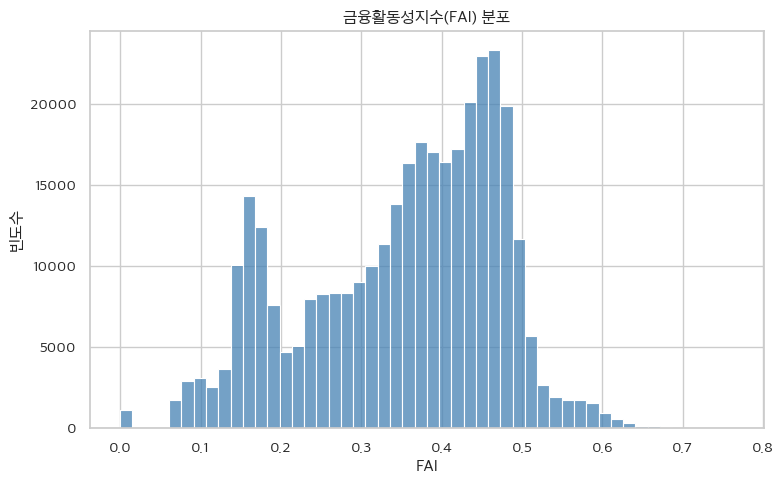

In [15]:
activity_summary = pd.DataFrame({
    '지표': ['규모점수', '빈도점수', '다양성점수', 'FAI'],
    '평균': [df2['규모점수'].mean(), df2['빈도점수'].mean(), df2['다양성점수'].mean(), df2['FAI'].mean()],
    '중앙값': [df2['규모점수'].median(), df2['빈도점수'].median(), df2['다양성점수'].median(), df2['FAI'].median()],
    '최소값': [df2['규모점수'].min(), df2['빈도점수'].min(), df2['다양성점수'].min(), df2['FAI'].min()],
    '최대값': [df2['규모점수'].max(), df2['빈도점수'].max(), df2['다양성점수'].max(), df2['FAI'].max()]
})
display(activity_summary)

plt.figure(figsize=(8, 5))
sns.histplot(df2['FAI'].dropna(), bins=50, color='steelblue')
plt.title('금융활동성지수(FAI) 분포')
plt.xlabel('FAI')
plt.ylabel('빈도수')
plt.tight_layout()
plt.show()
